# Decision Analysis 1

## Promethee

The objective of this laboratory session is to gain practical understanding of the **PROMETHEE** method – one of the most important *outranking* methods used in Multi-Criteria Decision Analysis (MCDA).

The PROMETHEE method is designed to rank a finite set of decision alternatives evaluated with respect to multiple, often conflicting criteria. It is based on pairwise comparisons of alternatives and uses the concept of the degree to which one alternative outranks another.

Within the method, for each criterion, the difference in evaluations between two alternatives is calculated. This difference is then transformed using a preference function into a value in the interval ⟨0,1⟩, representing the degree to which alternative *a* is preferred over alternative *b*. The resulting partial preference values are weighted and aggregated into a global preference index using a weighted average.

The next step of the method is the computation of aggregated measures called preference flows:

- **positive flow (φ⁺)** – represents the strength with which a given alternative outranks the others,
- **negative flow (φ⁻)** – represents the strength with which other alternatives outrank the given alternative.

In the case of **PROMETHEE II**, an additional measure is calculated:

- **net flow (φ)** – defined as the difference between the positive and negative flows.

In PROMETHEE II, the final ranking is based on the net flow – the higher the value of φ, the better the position of the alternative in the ranking. In contrast, PROMETHEE I provides a partial ranking based on the comparison of positive and negative flows, which may result in incomparability between some alternatives.

In the PROMETHEE family of methods, the decision maker provides preference information in the following form:

- **q** – indifference threshold,
- **p** – strict preference threshold,
- **w** – weight of criterion *k*,
- direction of preference (cost or benefit criterion).

> **IMPORTANT**
>
> Code written in this notebook will be checked against automatic code checker and the points will be given based on its' results, please leave the function signatures unchanged.
> As a result there are no partial points for a programing tasks

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import utils
from utils import display_ranking

In [2]:
# Loading dataset and preference information
data_path = Path("")
dataset = utils.load_dataset(data_path)
preference_information = utils.load_preference_information(data_path)

In [3]:
dataset

,G1,G2,G3
Alternative,,,
ITA,98,8,400
BEL,58,0,800
GER,66,5,1000
SWE,74,3,600
AUT,82,7,200
FRA,80,10,600


In [4]:
preference_information

,q,p,w,type
Criterion,,,,
G1,0,0,3,gain
G2,0,2,2,gain
G3,100,300,5,cost


### Task 1 (maximum points:  1)


Implement the `difference_function`. The function should calculate the difference between two alternatives with respect to a given criterion. The implementation must take into account the **criterion type**:

- for a **gain (maximization)** criterion:

  $d_k(a, b) = a − b$

- for a **cost (minimization)** criterion:

  $d(a, b) = b − a$

The function should return a single numeric value representing the difference used later in the marginal preference calculation.

In [5]:
def difference_function(alternative_a: float, alternative_b: float, criterion_type: utils.CriterionType) -> float:
    """
    Function that calculates the difference between given alternative pair on a single criterion.

    :param alternative_a: first alternative in a pair
    :param alternative_b: second alternative in a pair
    :param criterion_type: criterion type either gain or cost
    :return: difference between alternative pair calculated according to the criterion type
    """
    if criterion_type == utils.CriterionType.GAIN:
        return alternative_a - alternative_b
    else:
        return alternative_b - alternative_a

### Task 2 (maximum points:  1)


Implement the `marginal_preference_function`, that should compute the normalized marginal preference value based on:

- the difference value `diff`,
- the indifference threshold `indifference_threshold` ($q_k$),
- the strict preference threshold `preference_threshold` ($p_k$).

For computation please use the following formula:
$$
    \pi_k (a, b) = \left\{ \begin{array}{ll}
    1, & \textrm{if } d_k(a, b) > p_k,\\
    0, & \textrm{if } d_k(a, b) \leq q_k,\\
    \frac{d_k(a, b) - q_k} {p_k - q_k}, & \textrm{if } q_k < d_k(a, b) \leq p_k.
    \end{array} \right.
$$

In [6]:
def marginal_preference_function(diff: float, indifference_threshold: float, preference_threshold: float) -> float:
    """
    Function that calculates the marginal preference given a difference for a given thresholds.

    :param diff: difference between compared alternatives
    :param indifference_threshold: indifference threshold
    :param preference_threshold: preference threshold
    :return: float, representing the marginal preference index
    """
    if diff > preference_threshold:
        return 1.0
    elif diff <= indifference_threshold:
        return 0.0
    else:
        return (diff - indifference_threshold) / (preference_threshold - indifference_threshold)

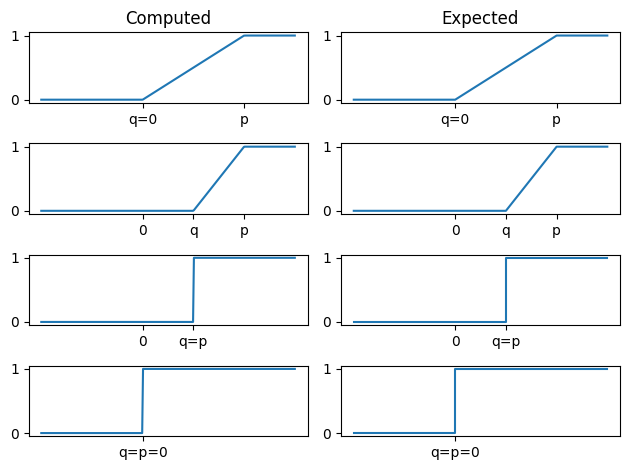

In [7]:
utils.test_marginal_preference_function(marginal_preference_function)

### Task 3 (maximum points:  1)


Implement the `calculate_marginal_preference_matrix` function.

The function should:

1. Compute the difference between every pair of alternatives for every criterion.
2. Apply the marginal preference function using the thresholds provided in `preference_information`.
3. Construct a 3-dimensional matrix containing marginal preference values for:
   - each pair of alternatives,
   - each criterion.

The output should be a NumPy array storing all marginal preference values.

In [8]:
def calculate_marginal_preference_matrix(dataset: pd.DataFrame, preference_information: pd.DataFrame) -> np.ndarray:
    """
    Function that calculates the marginal preference matrix all alternatives pairs and criterion available in dataset

    :param dataset: difference between compared alternatives
    :param preference_information: preference information
    :return: 3D numpy array with marginal preference matrix on every parser, Consecutive indices [i, j, k] describe first alternative, second alternative, parser
    """
    n_alts = len(dataset)
    n_criteria = len(dataset.columns)

    result = np.zeros((n_alts, n_alts, n_criteria))

    q = preference_information['q'].values
    p = preference_information['p'].values
    types = preference_information['type'].values

    for i in range(n_alts):
        for j in range(n_alts):
            for k in range(n_criteria):
                a_val = dataset.iloc[i, k]
                b_val = dataset.iloc[j, k]
                ctype = types[k]

                diff = difference_function(a_val, b_val, ctype)
                result[i, j, k] = marginal_preference_function(diff, q[k], p[k])

    return result

In [9]:
marginal_preference_matrix = calculate_marginal_preference_matrix(dataset, preference_information)

In [10]:
marginal_preference_matrix[4, 5]

array([1., 0., 1.])

### Task 4 (maximum points:  1)


Implement the `calculate_comprehensive_preference_index` function.

The function should aggregate marginal preference values across all criteria using criterion weights.

For each pair of alternatives (a, b), compute the comprehensive preference index:

$$\pi(a, b) = \frac{\sum w_k * \pi_k(a, b)}{\sum w_k}$$

where:
- $w_k$ is the weight of criterion k,
- $\pi_k(a, b)$ is the marginal preference value.

In [11]:
def calculate_comprehensive_preference_index(marginal_preference_matrix: np.ndarray, preference_information: pd.DataFrame) -> np.ndarray:
    """
    Function that calculates comprehensive preference index for the given dataset

    :param marginal_preference_matrix: 3D numpy array with marginal preference matrix on every parser, Consecutive indices [i, j, k] describe first alternative, second alternative, criterion
    :param preference_information: Padnas dataframe containing preference information
    :return: 2D numpy array with marginal preference matrix. Every entry in the matrix [i, j] represents comprehensive preference index between alternative i and alternative j
    """
    weights = preference_information['w'].values
    return np.sum(marginal_preference_matrix * weights, axis=2) / weights.sum()

In [12]:
comprehensive_preference_index = calculate_comprehensive_preference_index(marginal_preference_matrix, preference_information)

In [13]:
comprehensive_preference_index

array([[0.  , 1.  , 1.  , 0.75, 0.4 , 0.55],
       [0.  , 0.  , 0.25, 0.  , 0.  , 0.  ],
       [0.  , 0.5 , 0.  , 0.2 , 0.  , 0.  ],
       [0.  , 0.75, 0.8 , 0.  , 0.  , 0.  ],
       [0.25, 1.  , 1.  , 1.  , 0.  , 0.8 ],
       [0.2 , 0.75, 1.  , 0.5 , 0.2 , 0.  ]])

### Task 5 (maximum points:  1)


Implement three functions:

- `calculate_positive_flow`
- `calculate_negative_flow`
- `calculate_net_flow`

Positive flow (φ⁺):
Represents how strongly a given alternative outranks the others.
It is calculated as the average of preference indices in the corresponding row of the comprehensive preference matrix.

Negative flow (φ⁻):
Represents how strongly a given alternative is outranked by others.
It is calculated as the average of preference indices in the corresponding column.

Net flow (φ):
φ = φ⁺ − φ⁻

Each function should return a pandas Series indexed by alternatives.

In [14]:
def calculate_positive_flow(comprehensive_preference_matrix: np.ndarray, alternatives: pd.Index) -> pd.Series:
    """
    Function that calculates the positive flow value for the given preference matrix and corresponding index

    :param comprehensive_preference_matrix: 2D numpy array with marginal preference matrix. Every entry in the matrix [i, j] represents comprehensive preference index between alternative i and alternative j
    :param alternatives: index representing the alternative name in the corresponding position in preference matrix
    :return: series representing positive flow values for the given preference matrix
    """
    flows = comprehensive_preference_matrix.sum(axis=1)
    return pd.Series(flows, index=alternatives)

In [15]:
def calculate_negative_flow(comprehensive_preference_matrix: np.ndarray, alternatives: pd.Index) -> pd.Series:
    """
    Function that calculates the negative flow value for the given preference matrix and corresponding index

    :param comprehensive_preference_matrix: 2D numpy array with marginal preference matrix. Every entry in the matrix [i, j] represents comprehensive preference index between alternative i and alternative j
    :param alternatives: index representing the alternative name in the corresponding position in preference matrix
    :return: series representing negative flow values for the given preference matrix
    """
    flows = comprehensive_preference_matrix.sum(axis=0)
    return pd.Series(flows, index=alternatives)

In [16]:
def calculate_net_flow(positive_flow: pd.Series, negative_flow: pd.Series) -> pd.Series:
    """
    Function that calculates the net flow value for the given positive and negative flow

    :param positive_flow: series representing positive flow values for the given preference matrix
    :param negative_flow: series representing negative flow values for the given preference matrix
    :return: series representing net flow values for the given preference matrix
    """
    return positive_flow - negative_flow

In [17]:
positive_flow = calculate_positive_flow(comprehensive_preference_index, dataset.index)
negative_flow = calculate_negative_flow(comprehensive_preference_index, dataset.index)
net_flow = calculate_net_flow(positive_flow, negative_flow)

In [18]:
positive_flow

Alternative
ITA    3.70
BEL    0.25
GER    0.70
SWE    1.55
AUT    4.05
FRA    2.65
dtype: float64

In [19]:
negative_flow

Alternative
ITA    0.45
BEL    4.00
GER    4.05
SWE    2.45
AUT    0.60
FRA    1.35
dtype: float64

In [20]:
net_flow

Alternative
ITA    3.25
BEL   -3.75
GER   -3.35
SWE   -0.90
AUT    3.45
FRA    1.30
dtype: float64

### Task 6 (maximum points:  1)


Implement the `create_partial_ranking` function. The function should construct a partial ranking according to PROMETHEE I methodology, using:

- positive flow (φ⁺),
- negative flow (φ⁻).

The ranking should reflect dominance relations based on comparisons of positive and negative flows.

$$
    \text{a is preferred over b (a is higher in the ranking)} \Longleftrightarrow
    \begin{cases}
        \phi^+(a) > \phi^+(b) \text{ and } \phi^-(a) < \phi^-(b) \text{, or} \\
        \phi^+(a) = \phi^+(b) \text{ and } \phi^-(a) < \phi^-(b) \text{, or} \\
        \phi^+(a) > \phi^+(b) \text{ and } \phi^-(a) = \phi^-(b)
    \end{cases}
$$


$$
     \text{a is indifferent with b (a is higher in the ranking)} \Longleftrightarrow
    \phi^+(a) = \phi^+(b) \text{ and } \phi^-(a) = \phi^-(b)
$$

$$
    \text{a is incomparable with b} \Longleftrightarrow
    \begin{cases}
        \phi^+(a) > \phi^+(b) \text{ and } \phi^-(a) > \phi^-(b) \text{, or} \\
        \phi^+(a) < \phi^+(b) \text{ and } \phi^-(a) < \phi^-(b)
    \end{cases}
$$

The function should return a DataFrame where in index and columns are alternatives and cell indicate:
- 1- if for the give pair [i, j] the alternative i is preferred over j or i is indifferent from j
- 0- otherwise

In [21]:
def create_partial_ranking(positive_flow: pd.Series, negative_flow: pd.Series) -> pd.DataFrame:
    """
    Function that aggregates positive and negative flow to a partial ranking (from Promethee I)

    :param positive_flow: series representing positive flow values for the given preference matrix
    :param negative_flow: series representing negative flow values for the given preference matrix
    :return: partial ranking in a form of outranking matrix, as Dataframe where in index and columns are alternatives, i.e.
    1- if for the give pair [i, j] the alternative i is preferred over j or i is indifferent from j
    0- otherwise
    """
    alts = positive_flow.index
    n = len(alts)

    matrix = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            if positive_flow.iloc[i] >= positive_flow.iloc[j] and negative_flow.iloc[i] <= negative_flow.iloc[j]:
                matrix[i, j] = 1

    return pd.DataFrame(matrix, index=alts, columns=alts)

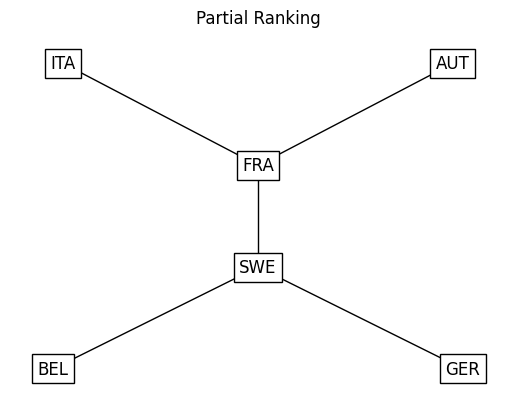

In [22]:
partial_ranking = create_partial_ranking(positive_flow, negative_flow)
display_ranking(partial_ranking, "Partial Ranking")

### Task 7 (maximum points:  1)


Implement the `create_complete_ranking` function.

The function should create a complete ranking according to PROMETHEE II methodology, based solely on the net flow (φ).

Alternatives should be sorted in descending order of net flow:
- higher φ → better rank.

The function should return a DataFrame where in index and columns are alternatives and cell indicate:
- 1- if for the give pair [i, j] the alternative i is preferred over j or i is indifferent from j
- 0- otherwise

In [23]:
def create_complete_ranking(net_flow: pd.Series) -> pd.DataFrame:
    """
    Function that aggregates positive and negative flow to a complete ranking (from Promethee II)
    :param net_flow: series representing net flow values for the given preference matrix
    :return: complete ranking in a form of outranking matrix, as Dataframe where in index and columns are alternatives, i.e.
    1- if for the give pair [i, j] the alternative i is preferred over j or i is indifferent from j
    0- otherwise
    """
    alts = net_flow.index
    n = len(alts)

    matrix = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            if net_flow.iloc[i] >= net_flow.iloc[j]:
                matrix[i, j] = 1

    return pd.DataFrame(matrix, index=alts, columns=alts)

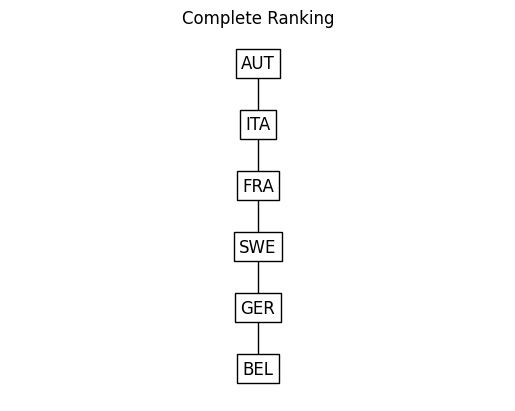

In [24]:
complete_ranking = create_complete_ranking(net_flow)
display_ranking(complete_ranking, "Complete Ranking")

## HOMEWORK

**Deadline:** 29.04.2026, 23:59

Using the implementation of the **PROMETHEE** method prepared above, the dataset from the UTA project is analysed below.
The decision-making problem is to find the best European country to live in from the perspective of a student based in Poznan.
The dataset contains 26 European countries evaluated on 8 criteria related to working conditions, quality of life and accessibility.


### Preference information

The criterion weights and the indifference / preference thresholds reflect the perspective of the decision maker.
The weight scale is two-tier: criteria considered as core indicators of quality of life (employment, unemployment, earnings, life expectancy, life satisfaction) receive `w=2`, while the secondary criteria related to working hours, air quality and distance from Poznan receive `w=1`.

For each criterion the indifference threshold `q` corresponds to roughly 5% of the criterion range and the preference threshold `p` to roughly 15% of the range. Differences below `q` are treated as practically the same, and differences above `p` already produce a clear preference for one alternative over another.

| criterion | type | q | p | w |
|---|---|---|---|---|
| Employment rate | gain | 1.5 | 4.0 | 2 |
| Long-term unemployment rate | cost | 0.5 | 1.5 | 2 |
| Personal earnings | gain | 2500 | 7000 | 2 |
| Life expectancy | gain | 0.5 | 1.5 | 2 |
| Life satisfaction | gain | 0.1 | 0.3 | 2 |
| Employees working very long hours | cost | 0.6 | 2.0 | 1 |
| Air pollution | cost | 1.0 | 3.0 | 1 |
| Distance from Poznan (km) | cost | 130 | 400 | 1 |

The same `q`, `p` and `w` values are reused in the ELECTRE Tri-B analysis (where additionally a veto threshold `v` is needed), so that the comparison between both methods relies on a single consistent specification of preferences.


In [25]:
dataset = pd.read_csv("dataset-uta/dataset.csv", index_col=0)
criteria_meta = pd.read_csv("dataset-uta/criteria_metadata.csv", index_col=0)
pairwise_preferences = pd.read_csv("dataset-uta/preferences.csv")

dataset

,Employment rate,Long-term unemployment rate,Personal earnings,Life expectancy,Life satisfaction,Employees working very long hours,Air pollution,Distance from Poznan (km)
Country,,,,,,,,
Austria,72.0,1.3,53132.0,82.0,7.2,5.3,12.2,468.5
Belgium,65.0,2.3,54327.0,82.1,6.8,4.3,12.8,883.8
Czech Republic,74.0,0.6,29885.0,79.3,6.9,4.5,17.0,311.7
Denmark,74.0,0.9,58430.0,81.5,7.5,1.1,10.0,461.5
Estonia,74.0,1.2,30720.0,78.8,6.5,2.2,5.9,920.1
Finland,72.0,1.2,46230.0,82.1,7.9,3.6,5.5,993.3
France,65.0,2.9,45581.0,82.9,6.7,7.7,11.4,1098.7
Germany,77.0,1.2,53745.0,81.4,7.3,3.9,12.0,238.8
Greece,56.0,10.8,27207.0,81.7,5.8,4.5,14.5,1688.1


In [26]:
preference_information = pd.DataFrame({
    'type': criteria_meta['nature'].values,
    'q': [1.5,   0.5,   2500.0,  0.5,  0.1,  0.6,  1.0,   130.0],
    'p': [4.0,   1.5,   7000.0,  1.5,  0.3,  2.0,  3.0,   400.0],
    'w': [2.0,   2.0,    2.0,    2.0,  2.0,  1.0,  1.0,     1.0],
}, index=dataset.columns)
preference_information.to_csv("dataset-uta/preference_information.csv")

preference_information

,type,q,p,w
Employment rate,gain,1.5,4.0,2.0
Long-term unemployment rate,cost,0.5,1.5,2.0
Personal earnings,gain,2500.0,7000.0,2.0
Life expectancy,gain,0.5,1.5,2.0
Life satisfaction,gain,0.1,0.3,2.0
Employees working very long hours,cost,0.6,2.0,1.0
Air pollution,cost,1.0,3.0,1.0
Distance from Poznan (km),cost,130.0,400.0,1.0


### Running the method

Below the full PROMETHEE pipeline is computed: marginal preference matrix, comprehensive preference index and the three flows.


In [27]:
marginal = calculate_marginal_preference_matrix(dataset, preference_information)
comprehensive = calculate_comprehensive_preference_index(marginal, preference_information)

pos = calculate_positive_flow(comprehensive, dataset.index)
neg = calculate_negative_flow(comprehensive, dataset.index)
net = calculate_net_flow(pos, neg)

flows = pd.DataFrame({'phi+': pos, 'phi-': neg, 'phi': net}).round(4)
flows.sort_values('phi', ascending=False)

,phi+,phi-,phi
Country,,,
Switzerland,16.4894,1.7202,14.7692
Norway,14.1210,2.2305,11.8905
Netherlands,14.2585,2.5652,11.6933
Iceland,15.4248,3.9703,11.4545
Sweden,13.7404,2.7422,10.9982
Denmark,13.5223,3.0855,10.4368
Germany,12.5720,4.2682,8.3038
Finland,11.9399,4.6744,7.2656
Luxembourg,11.3388,4.8603,6.4786


### Final results

The table above presents the positive (`phi+`), negative (`phi-`) and net (`phi`) flows for all 26 alternatives, sorted by the net flow.
A higher positive flow means the country outranks the others more strongly, a lower negative flow means it is outranked less often, and the net flow combines both into a single value used by PROMETHEE II.

The top of the ranking is Switzerland, Norway, Netherlands, Iceland and Sweden, followed by Denmark, Germany, Finland, Luxembourg and Austria. All ten leading countries combine high earnings, long life expectancy, low long-term unemployment and high life satisfaction, which are exactly the criteria with `w=2` in the preference information.

Iceland's fourth position is interesting: in the analogous ELECTRE Tri-B analysis the pessimistic assignment placed Iceland in the worst category, because both the share of employees working very long hours (11.7%) and the distance from Poznan (2 562.8 km) triggered the veto threshold. PROMETHEE has no veto mechanism, so Iceland's strong performance on earnings, life expectancy and life satisfaction compensates for these two weaknesses and pushes it into the top of the ranking.

The bottom of the ranking is Greece, followed by the Slovak Republic, Portugal, Italy and Hungary. Greece is a clear outlier with a net flow of -17.0 - the lowest employment rate in the dataset (56%), an extremely high long-term unemployment rate (10.8%), very low earnings and a large distance from Poznan. The remaining four countries at the bottom share a similar profile of low earnings (Slovak Republic, Hungary, Portugal), high air pollution (Slovak Republic, Hungary, Italy) or large distance from Poznan (Portugal, Italy).


### Complete ranking (PROMETHEE II)


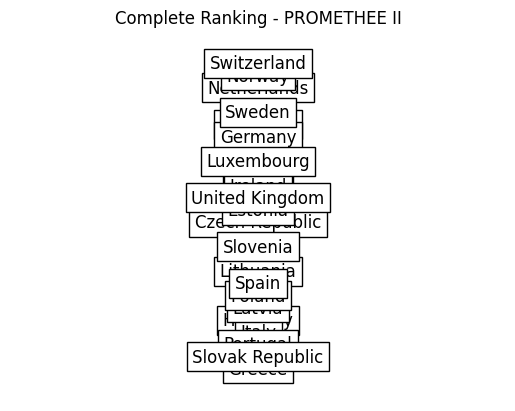

In [28]:
complete = create_complete_ranking(net)
display_ranking(complete, "Complete Ranking - PROMETHEE II")

### Partial ranking (PROMETHEE I)


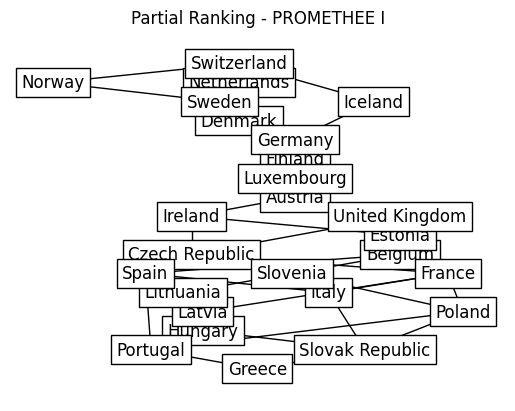

In [29]:
partial = create_partial_ranking(pos, neg)
display_ranking(partial, "Partial Ranking - PROMETHEE I")

In [30]:
# Pairs of alternatives that are incomparable in PROMETHEE I
alts = list(pos.index)
incomparable = []
for i in range(len(alts)):
    for j in range(i + 1, len(alts)):
        a, b = alts[i], alts[j]
        if partial.loc[a, b] == 0 and partial.loc[b, a] == 0:
            incomparable.append((a, b))

print(f"Number of incomparable pairs: {len(incomparable)}")
for a, b in incomparable:
    print(f"  {a:16s}  ?  {b}")

Number of incomparable pairs: 25
  Belgium           ?  Czech Republic
  Czech Republic    ?  Estonia
  Denmark           ?  Iceland
  France            ?  Lithuania
  France            ?  Slovenia
  France            ?  Spain
  Hungary           ?  Italy
  Hungary           ?  Poland
  Hungary           ?  Spain
  Iceland           ?  Netherlands
  Iceland           ?  Norway
  Iceland           ?  Sweden
  Ireland           ?  United Kingdom
  Italy             ?  Latvia
  Italy             ?  Lithuania
  Italy             ?  Poland
  Italy             ?  Portugal
  Latvia            ?  Poland
  Latvia            ?  Spain
  Lithuania         ?  Poland
  Lithuania         ?  Spain
  Netherlands       ?  Norway
  Poland            ?  Spain
  Portugal          ?  Slovak Republic
  Slovenia          ?  Spain


### Comparison of complete and partial rankings

The complete ranking from PROMETHEE II provides a single linear ordering based purely on the net flow. It is convenient because every pair of alternatives can be compared, but the trade-off between strong positive flow and strong negative flow is hidden inside the subtraction.

The partial ranking from PROMETHEE I is more cautious - it leaves a pair of alternatives *incomparable* whenever one of them has both a higher `phi+` and a higher `phi-` than the other.
This is the situation in which one country is more often preferred to the others, but is also more often outranked, so the two flows do not agree on which alternative is better.

For the analysed dataset PROMETHEE I marks 25 pairs as incomparable. Most of them sit in the middle of the ranking (Belgium / Czech Republic, France / Lithuania, Italy / Poland, Latvia / Spain etc.), where the net flows are close and the two component flows do not agree on the ordering.
A more visible case is Iceland - it is incomparable with all four of its neighbours in the complete ranking (Denmark, Netherlands, Norway and Sweden). Iceland has a higher `phi+` than each of them (it strongly outranks the bottom of the ranking) but also a higher `phi-` (long working hours and large distance from Poznan generate preferences against it), so the partial ranking does not commit to an ordering with the four Nordic neighbours.

For every country that is not part of an incomparable pair the two rankings are consistent, so the complete and partial rankings tell the same story for the most clear-cut cases and differ only in the borderline zone.


### Pairwise preferences from the dataset report

The dataset report from the UTA project lists 20 pairwise preferences expressing the decision maker's expert knowledge.
A preference *A > B* is satisfied by PROMETHEE if the net flow of *A* is strictly greater than the net flow of *B*.


In [31]:
checks = []
for _, row in pairwise_preferences.iterrows():
    a, b = row['preferred'], row['over']
    phi_a = net.loc[a]
    phi_b = net.loc[b]
    checks.append({
        'preferred': a,
        'over': b,
        'phi_preferred': round(phi_a, 4),
        'phi_over': round(phi_b, 4),
        'satisfied': phi_a > phi_b,
    })

checks_df = pd.DataFrame(checks)
print(checks_df.to_string(index=False))
print(f"\nSatisfied: {checks_df['satisfied'].sum()} / {len(checks_df)}")

     preferred           over  phi_preferred  phi_over  satisfied
   Switzerland    Netherlands        14.7692   11.6933       True
       Germany Czech Republic         8.3038   -1.7974       True
        Norway United Kingdom        11.8905    1.1477       True
       Finland         Poland         7.2656   -7.4614       True
   Netherlands        Belgium        11.6933   -2.4144       True
    Luxembourg        Ireland         6.4786    1.6887       True
       Germany       Slovenia         8.3038   -4.5898       True
       Denmark         Sweden        10.4368   10.9982      False
        Sweden         Norway        10.9982   11.8905      False
        Norway        Denmark        11.8905   10.4368       True
       Finland        Austria         7.2656    4.9739       True
        Sweden        Austria        10.9982    4.9739       True
       Finland        Ireland         7.2656    1.6887       True
       Estonia         France        -1.4220   -5.1918       True
Czech Repu

### Best and worst alternatives


In [32]:
ranking = flows.sort_values('phi', ascending=False)

print("Top 5 alternatives")
print(dataset.loc[ranking.head(5).index].to_string())

print("\nBottom 5 alternatives")
print(dataset.loc[ranking.tail(5).index].to_string())

Top 5 alternatives
             Employment rate  Long-term unemployment rate  Personal earnings  Life expectancy  Life satisfaction  Employees working very long hours  Air pollution  Distance from Poznan (km)
Country                                                                                                                                                                                      
Switzerland             80.0                          1.7            64824.0             84.0                7.5                                0.4           10.1                      911.6
Norway                  75.0                          0.9            55780.0             83.0                7.3                                1.4            6.7                      917.2
Netherlands             78.0                          0.9            58828.0             82.2                7.5                                0.3           12.2                      814.9
Iceland                 78.0   

### Discussion

**Top of the ranking.** Switzerland comes out as the best alternative, followed by Norway, Netherlands, Iceland and Sweden. Switzerland has the highest employment rate in the dataset (80%), very high earnings (64 824 USD/year), the longest life expectancy (84.0 years), the second lowest share of employees working very long hours (0.4%) and a moderate distance from Poznan. The next four positions follow the same pattern: high earnings, long life expectancy, low unemployment and a low or moderate distance from Poznan. Iceland is a slightly atypical case - despite the longest distance from Poznan in the dataset (2 562.8 km) and the highest share of employees working very long hours (11.7%), its very high earnings (67 488 USD/year, the highest in the dataset) and long life expectancy (83.2 years) compensate for these two weaknesses and place it in the top five.

**Bottom of the ranking.** The worst country is Greece, with a clear gap to the rest of the dataset. Greece combines the lowest employment rate (56%), an extremely high long-term unemployment rate (10.8%) - by far the highest in the dataset - very low earnings and a large distance from Poznan. The next four worst alternatives are the Slovak Republic, Portugal, Italy and Hungary. Each of them has a different combination of weaknesses: the Slovak Republic suffers from the lowest earnings in the whole dataset (23 619 USD/year) together with very high air pollution (18.5 μg/m³), Portugal combines low earnings (28 410 USD/year) with the second largest distance from Poznan (2 513 km), Hungary combines low earnings (25 409 USD/year) with high air pollution (16.7 μg/m³), and Italy is dragged down mostly by the second lowest employment rate (58%), a high long-term unemployment rate (4.8%), high air pollution (15.9 μg/m³) and a long distance from Poznan (1 214 km).

**Coverage of the pairwise preferences.** Out of the 20 pairwise preferences specified by the decision maker, 16 are satisfied by the PROMETHEE ranking. The four violations all involve very small net flow differences between adjacent positions:

- *Denmark > Sweden* and *Sweden > Norway* in the top group - all three are within 1.5 of each other in the net flow (Denmark 10.44, Sweden 11.00, Norway 11.89),
- *Lithuania > Slovenia* and *Lithuania > France* in the middle group - again with net flow differences below 1.6 (Lithuania -6.13, Slovenia -4.59, France -5.19).

These are the borderline situations in which the partial ranking from PROMETHEE I would mark the involved pairs as either close to indifferent or incomparable, so the violations should not be read as serious errors of the model. The result confirms that the chosen weights and thresholds are consistent with the decision maker's expert knowledge.
